In [1]:
# %%
import sys
sys.path.insert(0, '/home/frlab/mj_opt/mj_sim/manipulator')

import numpy as np
import mujoco
import mujoco.viewer
import pinocchio as pin
from pinocchio import rpy
from core import FixedBaseRobotState, Pinocchio_Wrapper, Mujoco_Kernel
from utils import SimScheduler, Visualizer, DataLogger, plot_helpers
from control import TaskSpaceController, TrajectoryGenerator

%load_ext autoreload
%autoreload 2

MJCF = '/home/frlab/mj_opt/xmls/systems/universal_robots_ur5e/scene_torque.xml'
URDF = '/home/frlab/mj_opt/xmls/robots/ur_description/urdf/ur5e.urdf'
PKG = '/home/frlab/mj_opt/xmls/robots'

orchestrator 구성

In [2]:

class RobotOrchestrator:
    def __init__(self, kernel, wrapper, controller, traj, logger=None):
        self.kernel = kernel
        self.wrapper = wrapper
        self.controller = controller
        self.traj = traj
        self.logger = logger
        
        # --- 메모리 미리 할당 (Pre-allocation) ---
        self.target_pos = np.zeros(3)
        self.target_R = np.eye(3)
        self.target_twist = np.zeros(6)
        
        self.current_ee_pos = np.zeros(3)
        self.current_ee_R = np.eye(3)
        self.current_twist = np.zeros(6)
        
        self.ctrl_tau = np.zeros(wrapper.nv)

    def on_control(self, t):
        # 1. 상태 업데이트
        self.kernel.update_robot_state(state)
        self.wrapper.update_model(state.q, state.dq)
        
        # 2. 궤적 평가
        interpolated_oM_ee, target_twist_new = self.traj.evaluate(t)
        self.target_pos[:] = interpolated_oM_ee.translation
        self.target_R[:] = interpolated_oM_ee.rotation
        self.target_twist[:] = target_twist_new
        
        # 3. 현재 EE 상태 가져오기
        oMf, v_lin, v_ang = self.wrapper.ee_state_world("ee")
        self.current_ee_pos[:] = oMf.translation
        self.current_ee_R[:] = oMf.rotation
        self.current_twist[:3] = v_lin
        self.current_twist[3:] = v_ang

        # 4. 제어 연산
        pose_err, twist_err = self.controller.compute_error(
            self.current_ee_pos, self.current_ee_R, self.current_twist,
            self.target_pos, self.target_R, self.target_twist
        )
        
        # 5. 토크 인가
        self.ctrl_tau[:] = self.controller.compute_impedance_torque(
            pose_err, twist_err, self.wrapper.J_world("ee"), self.wrapper.M_inv, self.wrapper.nle
        )
        self.kernel.ctrl_tau = self.ctrl_tau

        # 6. 데이터 로깅 (들여쓰기 주의: 반드시 on_control 함수 안에 있어야 합니다!)
        if self.logger is not None:
            self.logger.log(
                times=t,
                target_pos=self.target_pos,
                actual_pos=self.current_ee_pos,
                target_vel=self.target_twist[:3],
                actual_vel=self.current_twist[:3],
                cmd_tau=self.ctrl_tau[:6],                  
                act_tau=self.kernel.data.qfrc_actuator[:6],
                q=self.kernel.data.qpos[:6],
                dq=self.kernel.data.qvel[:6],
                ddq=self.kernel.data.qacc[:6],
            )

    def on_render(self, t, visualizer):
        visualizer.draw_axes(self.current_ee_pos, self.current_ee_R, size=0.2)
        visualizer.draw_axes(self.target_pos, self.target_R, size=0.2)

상태 초기화, wrapper 호출, 커널 호출, 제어기 호출, 초기 ee SE3, SO3, x, y, z 추출 (피노키오 컨벤션)

In [3]:
state    = FixedBaseRobotState()
wrapper  = Pinocchio_Wrapper(URDF, PKG)
joint_names = [wrapper.model.names[i] for i in range(1, wrapper.model.njoints)]
kernel   = Mujoco_Kernel(MJCF, joint_names_pin_order=joint_names)
controller = TaskSpaceController(wrapper)   

print("✅ 시스템 호출 완료")

q_init = kernel.q_keyframe
dq_init = np.zeros(wrapper.nv)
wrapper.update_model(q_init, dq_init)

oM_ee_init = wrapper.oM_ee
init_ee_pos = oM_ee_init.translation.copy()
init_ee_R = oM_ee_init.rotation.copy()

print(f"초기 end-effector 위치 x,y,z: \n{init_ee_pos}")
print(f"초기 end-effector 방향 SO(3): \n{init_ee_R}")

✅ 시스템 호출 완료
초기 end-effector 위치 x,y,z: 
[ 0.13329783 -0.49189929  0.48790037]
초기 end-effector 방향 SO(3): 
[[-1.00000000e+00  3.67341021e-06 -3.67342370e-06]
 [ 3.67342370e-06  1.00000000e+00 -3.67298651e-06]
 [ 3.67341021e-06 -3.67300000e-06 -1.00000000e+00]]


In [4]:
# 목표 위치 설정
wp_pos = [init_ee_pos,
          init_ee_pos + np.array([-0.2, 0.2, -0.1]),
          init_ee_pos + np.array([0.1, 0.0, -0.25]),
          init_ee_pos + np.array([-0.0, -0.1, -0.3]),
          init_ee_pos + np.array([-0.1, 0.2, -0.1]),
          init_ee_pos + np.array([-0.2, -0.1, -0.1]),
          init_ee_pos + np.array([0.4, 0.3, 0.0])]
    
# 목표 R 설정
wp_rot = [
        init_ee_R,
        init_ee_R @ rpy.rpyToMatrix(0,       0,      np.pi/4),
        init_ee_R @ rpy.rpyToMatrix(0,  np.pi/6,          0),
        init_ee_R @ rpy.rpyToMatrix(0,       0,      np.pi/2),
        init_ee_R @ rpy.rpyToMatrix(np.pi/6,       np.pi/6,  np.pi/2),
        init_ee_R @ rpy.rpyToMatrix(0,       np.pi/6,  0),
        init_ee_R @ rpy.rpyToMatrix(np.pi/6,       0,      0),]

# 경로 생성
traj = TrajectoryGenerator(
    wp_list=wp_pos,
    R_list=wp_rot,
    target_speed=0.1
)

Main Loop (상태 갱신, 제어, 뷰어, 시각화)

In [5]:
# 실행 직전 초기화 
kernel.reset_to_keyframe()
logger = DataLogger()

# 오케스트레이터 및 스케줄러 실행
orch = RobotOrchestrator(kernel, wrapper, controller, traj, logger) 
sched = SimScheduler(kernel.model, kernel.data, ctrl_hz=500, render_hz=60)
sched.run(on_control=orch.on_control, on_render=orch.on_render)

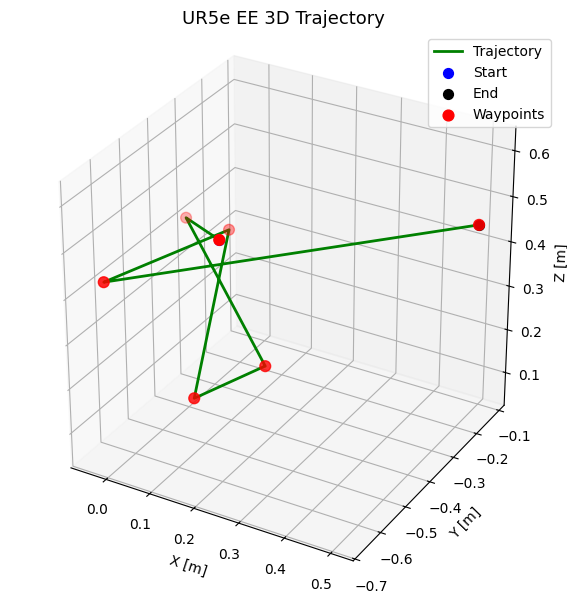

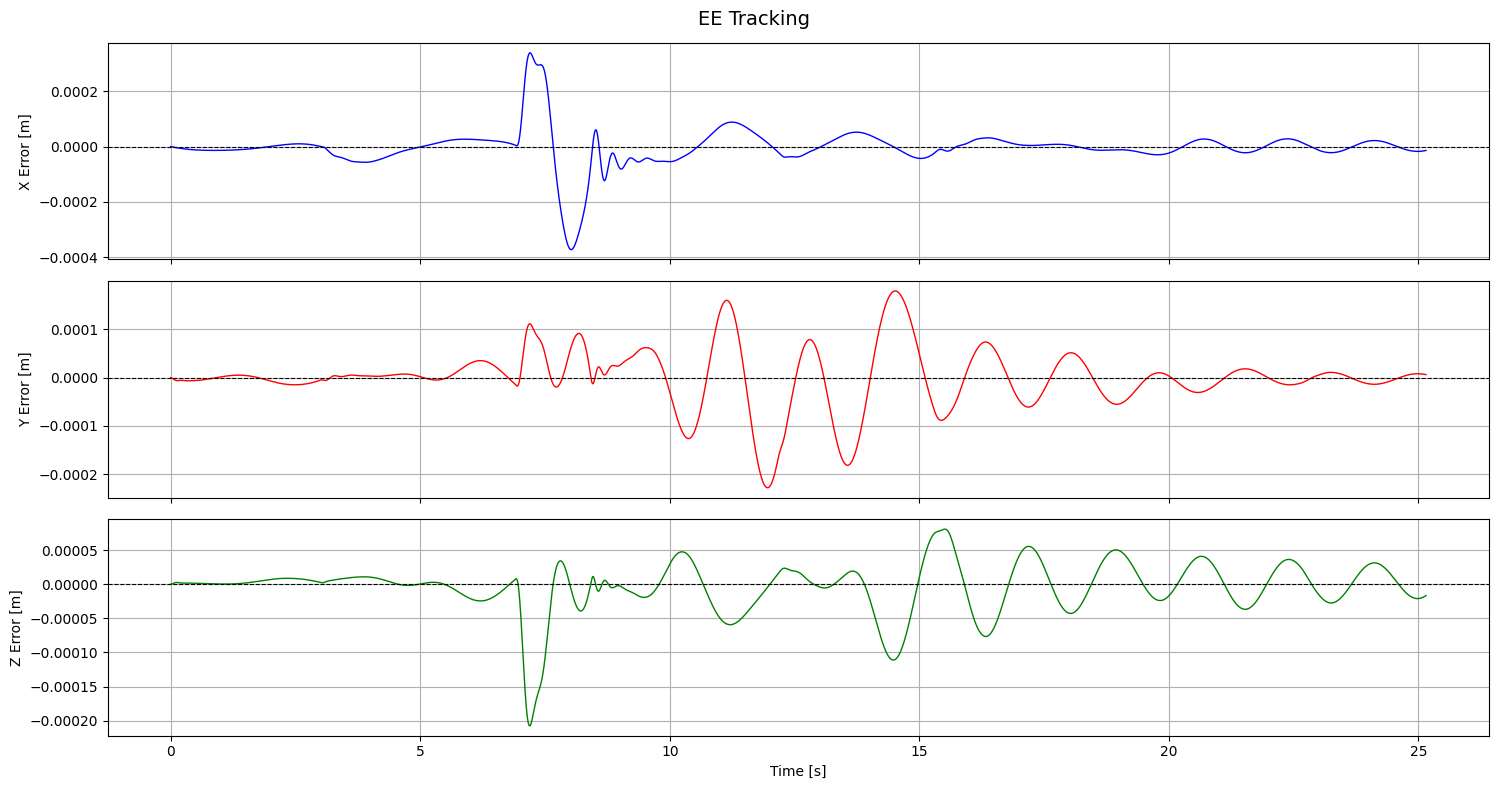

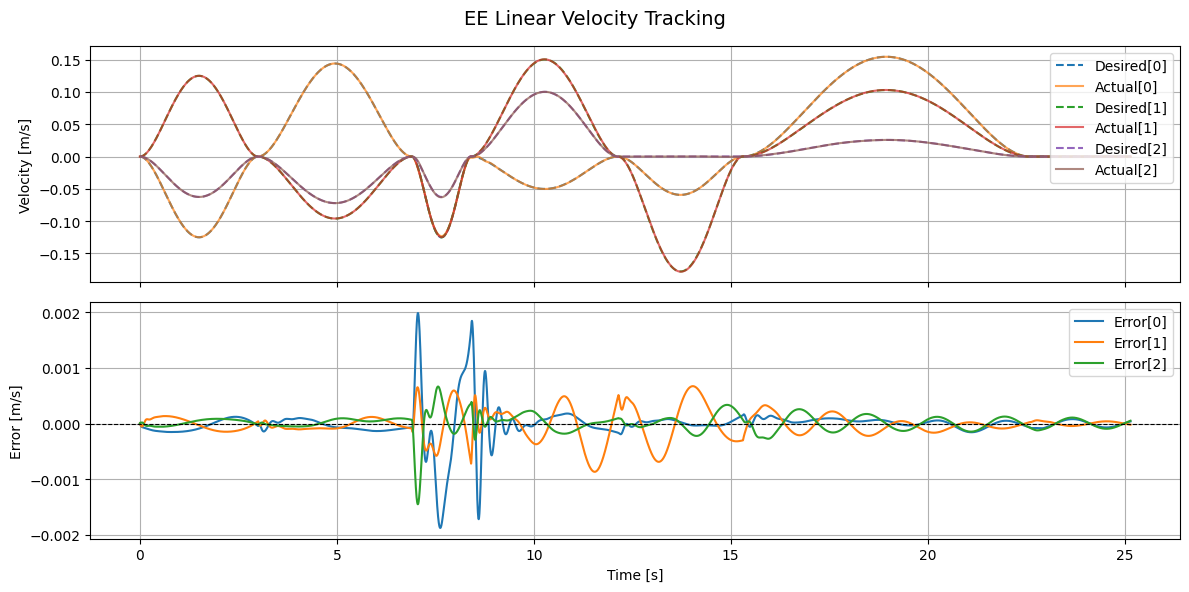

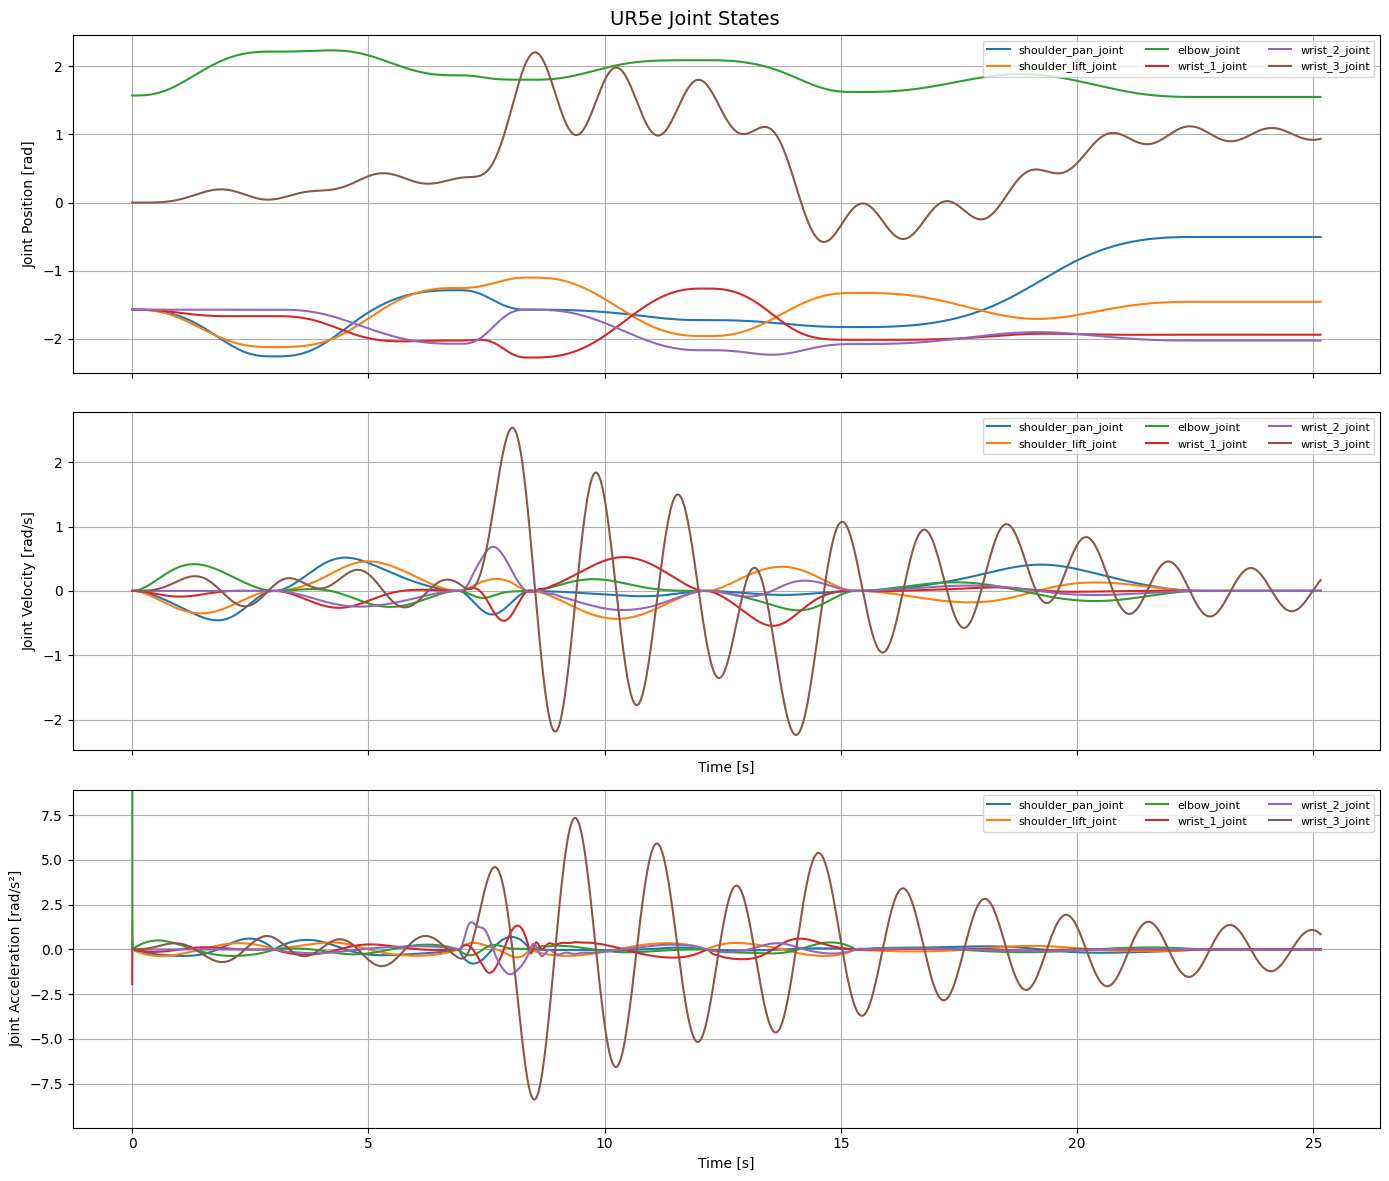

In [6]:
# 1. 로거에서 데이터 일괄 추출 (Numpy Array 형태)
times = logger.get('times')
target_pos = logger.get('target_pos')
actual_pos = logger.get('actual_pos')
target_vel = logger.get('target_vel')
actual_vel = logger.get('actual_vel')
q = logger.get('q')
dq = logger.get('dq')
ddq = logger.get('ddq')

# 2. 플로팅 함수 호출
# 2-1. 3D 궤적 (실제 이동 경로와 waypoints 비교)
plot_helpers.plot_3d_trajectory(
    pos_log=actual_pos, 
    waypoints=wp_pos, 
    title="UR5e EE 3D Trajectory"
)

# 2-2. X, Y, Z 위치 추종 오차
plot_helpers.plot_ee_tracking(
    times=times, 
    desired=target_pos, 
    actual=actual_pos
)

# 2-3. 선속도 추종 성능 (X, Y, Z 각각 다차원 plot 지원됨)
plot_helpers.plot_velocity_tracking(
    times=times, 
    des_vel=target_vel, 
    act_vel=actual_vel, 
    title="EE Linear Velocity Tracking"
)

# 2-4. 관절 위치 및 속도 상태
plot_helpers.plot_joint_state(
    times=times, 
    q=q, 
    dq=dq, 
    ddq=ddq,
    joint_names=joint_names[:6], # UR5e 관절 이름
    title="UR5e Joint States"
)

# 3. 모든 창이 닫힐 때까지 대기 (Jupyter나 스크립트 종료 방지)
plot_helpers.hold_until_all_fig_closed()